# CISC7021 Applied NLP - Assignment 1: Build a Toy Llama-2 Language Model

Submission notebook. Everything below was run on my own laptop (NVIDIA GeForce RTX 4070 Laptop GPU, CUDA 12.4, PyTorch 2.6.0).

The assignment has three tasks, all built on the tiny `llama-42m` checkpoint:

1. Task 1 - decoding: greedy vs. stochastic decoding (temperature / top-k / top-p) on English prefixes.
2. Task 2 - perplexity: an English-only pretrained toy model, tested on English, Chinese and Portuguese data.
3. Task 3 - continual pre-training on Chinese: keep training `llama-42m` on a Chinese story corpus, then check what it gained and how much English it kept.

For the hyper-parameter study I trained three configurations from scratch inside this notebook: Run A (lr 1e-4, 8 epochs), Run B (lr 5e-5, 8 epochs) and Run C (lr 1e-4, 2 epochs). Task 4 then adds more Chinese data (TinyStories translated with NLLB-200) and a fourth run D. The full discussion is in the LaTeX report that goes with this notebook.


## 0. Environment setup

I installed the heavy packages (`torch` 2.6.0+cu124, `transformers`, `datasets`, `accelerate`) into a conda environment called `cisc7021` before running anything. The cell below only prints the versions I ended up with, so the numbers in this notebook can be traced back to one specific setup.


In [1]:

# -*- coding: utf-8 -*-
import sys, io, os, time, json, math, gc, statistics
try:
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding="utf-8")
except Exception:
    pass

import numpy as np
import torch
import transformers, datasets, accelerate

print("python", sys.version.split()[0])
print("torch", torch.__version__, "| cuda available:", torch.cuda.is_available())
print("transformers", transformers.__version__, "| datasets", datasets.__version__)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0), "| mem(GB):", round(torch.cuda.get_device_properties(0).total_memory/1e9, 1))


python 3.11.16


torch 2.6.0+cu124 | cuda available: True
transformers 4.46.3 | datasets 5.0.1
gpu: NVIDIA GeForce RTX 4070 Laptop GPU | mem(GB): 8.6


## 1. Model and data paths

I first wrote this notebook for Colab (`/content/drive/...`) and later moved everything to my laptop. All paths below point to local copies of the checkpoint and the JSONL data.


In [2]:

DATA_DIR  = r"C:\Users\07viv\Desktop\CISC7021\Model and Datasets\data"
MODEL_DIR = r"C:\Users\07viv\Desktop\CISC7021\Model and Datasets\llama-42m"

TRAIN_FILE      = os.path.join(DATA_DIR, "zh_train.jsonl")   # Chinese stories for continual pre-training
VALIDATION_FILE = os.path.join(DATA_DIR, "zh_dev.jsonl")
ZH_TEST_FILE    = os.path.join(DATA_DIR, "zh_test.jsonl")
EN_TEST_FILE    = os.path.join(DATA_DIR, "en_test.jsonl")
PT_TEST_FILE    = os.path.join(DATA_DIR, "pt_test.jsonl")

OUT_DIR = r"C:\Users\07viv\Desktop\CISC7021\assignment1_artifacts"
FINAL_ROOT = r"C:\Users\07viv\Desktop\CISC7021\saved_models"
os.makedirs(OUT_DIR, exist_ok=True)
print("all paths ok:", all(os.path.exists(p) for p in [DATA_DIR, MODEL_DIR, TRAIN_FILE, VALIDATION_FILE, ZH_TEST_FILE, EN_TEST_FILE, PT_TEST_FILE]))


all paths ok: True


Loading the checkpoint. It was pre-trained on English only: a 41.7M-parameter decoder-only model (hidden size 512, 8 layers, 8 heads, vocabulary 32k) from the same architecture family as Llama-2.


In [3]:

from transformers import LlamaForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = LlamaForCausalLM.from_pretrained(MODEL_DIR).to(device)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

total_para = sum(v.numel() for k, v in model.state_dict().items() if k != "model.embed_tokens.weight")
total_para_all = sum(v.numel() for v in model.state_dict().values())
print(f"model parameters (excluding embedding): {total_para/1e6:.2f}M")
print(f"model parameters (all):                {total_para_all/1e6:.2f}M")
print("vocab size:", tokenizer.vocab_size, "| pad:", tokenizer.pad_token, "| eos:", tokenizer.eos_token)
print(model.config)


device: cuda


model parameters (excluding embedding): 41.69M
model parameters (all):                58.07M
vocab size: 32000 | pad: </s> | eos: </s>
LlamaConfig {
  "_attn_implementation_autoset": true,
  "_name_or_path": "C:\\Users\\07viv\\Desktop\\CISC7021\\Model and Datasets\\llama-42m",
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 1,
  "eos_token_id": 2,
  "head_dim": 64,
  "hidden_act": "silu",
  "hidden_size": 512,
  "initializer_range": 0.02,
  "intermediate_size": 1376,
  "max_position_embeddings": 1024,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 8,
  "num_hidden_layers": 8,
  "num_key_value_heads": 8,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-05,
  "rope_scaling": null,
  "rope_theta": 10000.0,
  "tie_word_embeddings": true,
  "transformers_version": "4.46.3",
  "use_cache": true,
  "vocab_size": 32000
}



## 2. Task 1 - Decoding

I call `model.generate()` six times with different decoding settings on English story prefixes:

| name | strategy |
|---|---|
| `greedy` | greedy search |
| `temp_0.3` | sampling, temperature 0.3 |
| `temp_0.6` | sampling, temperature 0.6 |
| `temp_1.0` | sampling, temperature 1.0 |
| `temp0.8_k50` | temperature 0.8 + top-k (k=50) |
| `temp0.8_p90` | temperature 0.8 + top-p (p=0.90) |

The code prints one excerpt per configuration, then computes a few simple lexical statistics on the outputs: length, type-token ratio (TTR) and repeated bigram/trigram ratios. I seed everything, so the numbers stay the same if the notebook is re-run.


In [4]:

def seed_all(seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def generate_text(prompt, max_new_tokens=120, do_sample=False, temperature=1.0,
                  top_k=None, top_p=None, seed=42):
    seed_all(seed)
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    gen_kwargs = dict(max_new_tokens=max_new_tokens, do_sample=do_sample, pad_token_id=tokenizer.pad_token_id)
    if do_sample:
        gen_kwargs["temperature"] = temperature
        if top_k is not None: gen_kwargs["top_k"] = top_k
        if top_p is not None: gen_kwargs["top_p"] = top_p
    else:
        # Greedy decoding: explicitly unset sampling-only knobs, otherwise the
        # base checkpoint generation_config (temperature=0.6, top_p=0.9) makes
        # model.generate() raise harmless HuggingFace UserWarnings.
        gen_kwargs["temperature"] = None
        gen_kwargs["top_p"] = None
        gen_kwargs["top_k"] = None
    out = model.generate(**inputs, **gen_kwargs)
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    return text, len(inputs.input_ids[0]), len(out[0])

def lex_stats(text):
    words = text.split()
    n = len(words)
    if n == 0: return {"words": 0, "ttr": float("nan"), "rep2": float("nan"), "rep3": float("nan")}
    uniq = len(set(words))
    bigrams  = [tuple(words[i:i+2]) for i in range(n-1)]
    trigrams = [tuple(words[i:i+3]) for i in range(n-2)]
    rep2 = 1.0 - len(set(bigrams)) / max(len(bigrams), 1)
    rep3 = 1.0 - len(set(trigrams)) / max(len(trigrams), 1)
    return {"words": n, "ttr": uniq/n, "rep2": round(rep2, 4), "rep3": round(rep3, 4)}

CONFIGS = [
    ("greedy",       dict(do_sample=False)),
    ("temp_0.3",     dict(do_sample=True, temperature=0.3)),
    ("temp_0.6",     dict(do_sample=True, temperature=0.6)),
    ("temp_1.0",     dict(do_sample=True, temperature=1.0)),
    ("temp0.8_k50",  dict(do_sample=True, temperature=0.8, top_k=50)),
    ("temp0.8_p90",  dict(do_sample=True, temperature=0.8, top_p=0.90)),
]

EN_PROMPTS = [
    "Once upon a time, Stella Lou had a dream.",
    "In a small village near the forest, there lived an old carpenter.",
    "A scientist discovered a strange door in the laboratory.",
]


In [5]:

import pandas as pd

rows = []
excerpts = []
for pi, prompt in enumerate(EN_PROMPTS):
    for name, kw in CONFIGS:
        text, in_len, out_len = generate_text(prompt, **kw)
        body = text[len(prompt):]
        st = lex_stats(body)
        rows.append({"prompt": f"en_{chr(ord('a')+pi)}", "setting": name, "words": st["words"],
                     "ttr": st["ttr"], "rep2": st["rep2"], "rep3": st["rep3"]})
        excerpts.append({"prompt": f"en_{chr(ord('a')+pi)}", "setting": name,
                         "excerpt": body[:140].replace("\n", " ")})

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print("\n--- excerpts (first 140 chars of the continuation) ---")
for e in excerpts[:12]:
    print(f"[{e['prompt']} | {e['setting']}] {e['excerpt']}")


prompt     setting  words      ttr   rep2   rep3
  en_a      greedy     90 0.666667 0.0562 0.0114
  en_a    temp_0.3     91 0.615385 0.0889 0.0225
  en_a    temp_0.6     82 0.731707 0.0741 0.0500
  en_a    temp_1.0     95 0.673684 0.0319 0.0000
  en_a temp0.8_k50     87 0.666667 0.0233 0.0000
  en_a temp0.8_p90     87 0.666667 0.0233 0.0000
  en_b      greedy     94 0.531915 0.1935 0.0761
  en_b    temp_0.3     93 0.580645 0.1848 0.0659
  en_b    temp_0.6     93 0.655914 0.0761 0.0220
  en_b    temp_1.0     86 0.709302 0.0235 0.0000
  en_b temp0.8_k50     93 0.655914 0.0652 0.0220
  en_b temp0.8_p90     93 0.655914 0.0652 0.0220
  en_c      greedy    103 0.621359 0.0784 0.0198
  en_c    temp_0.3    102 0.627451 0.0990 0.0300
  en_c    temp_0.6     97 0.556701 0.1979 0.0947
  en_c    temp_1.0     99 0.646465 0.0306 0.0000
  en_c temp0.8_k50     93 0.677419 0.0543 0.0000
  en_c temp0.8_p90     93 0.677419 0.0543 0.0000

--- excerpts (first 140 chars of the continuation) ---
[en_a | greed

In [6]:

print("aggregated by decoding setting")
agg = df.groupby("setting").agg(words=("words","mean"), ttr=("ttr","mean"),
                                rep2=("rep2","mean"), rep3=("rep3","mean")).round(4)
print(agg.to_string())

# save for cross-checking with the report
df.to_csv(os.path.join(OUT_DIR, "task1_metrics.csv"), index=False)
print("saved:", os.path.join(OUT_DIR, "task1_metrics.csv"))


aggregated by decoding setting
               words     ttr    rep2    rep3
setting                                     
greedy       95.6667  0.6066  0.1094  0.0358
temp0.8_k50  91.0000  0.6667  0.0476  0.0073
temp0.8_p90  91.0000  0.6667  0.0476  0.0073
temp_0.3     95.3333  0.6078  0.1242  0.0395
temp_0.6     90.6667  0.6481  0.1160  0.0556
temp_1.0     93.3333  0.6765  0.0287  0.0000
saved: C:\Users\07viv\Desktop\CISC7021\assignment1_artifacts\task1_metrics.csv


### What about other languages?

`llama-42m` only saw English during pre-training, so a Chinese prefix sits outside its training distribution. It keeps producing English-like text instead of switching to Chinese.


In [7]:

zh_prompt = "从前有一只小兔子乖乖"   # a Chinese story prefix
text, _, _ = generate_text(zh_prompt, max_new_tokens=80, do_sample=True, temperature=0.6)
print("input :", zh_prompt)
print("output:", text[len(zh_prompt):])


input : 从前有一只小兔子乖乖
output: ons were playing in the garden. Suddenly, he noticed a big, yellow butterfly. He was so excited that he ran over to it.
"Look, Mommy!" he said, pointing at the butterfly.
Mommy smiled and said, "That's a beautiful butterfly, isn't it?"
Little Timmy nodded


## 3. Task 2 - Perplexity evaluation

Quick background: for a document $w_1\dots w_N$, perplexity is
$\exp\left(-\frac{1}{N}\sum_{t}\log p_\theta(w_t \mid w_{<t})\right)$,
and a lower PPL means the model gives the text a higher probability.

I adapted the function below from the `evaluate` library (Apache License 2.0) so that it accepts local paths directly. On the GPU the forward pass runs in fp16, and I move the per-document mean log-likelihood to fp32 before taking `exp()`. Without that step the Chinese documents, whose PPL is huge, overflow to `inf`.


In [8]:

from torch.nn import CrossEntropyLoss

def compute_ppl(model, tokenizer, texts, batch_size=16, max_length=None,
                add_start_token=True, use_fp16=True):
    """Return per-document perplexities + aggregates for a list of raw texts."""
    encodings = tokenizer(texts, add_special_tokens=False, truncation=False, return_tensors=None)
    seq_lens = [len(ids) for ids in encodings["input_ids"]]
    if max_length:
        encodings = tokenizer(texts, add_special_tokens=False, truncation=True,
                              max_length=max_length, return_tensors=None)
        seq_lens = [min(l, max_length) for l in seq_lens]

    encoded_texts = []
    attn_masks = []
    for ids, mask in zip(encodings["input_ids"], encodings["attention_mask"]):
        encoded_texts.append(torch.tensor(ids, dtype=torch.long))
        attn_masks.append(torch.tensor(mask, dtype=torch.long))
    encoded_texts = torch.nn.utils.rnn.pad_sequence(encoded_texts, batch_first=True, padding_value=tokenizer.pad_token_id)
    attn_masks = torch.nn.utils.rnn.pad_sequence(attn_masks, batch_first=True, padding_value=0)

    if add_start_token and tokenizer.bos_token_id is not None:
        bos = torch.full((encoded_texts.size(0), 1), tokenizer.bos_token_id, dtype=torch.long)
        encoded_texts = torch.cat([bos, encoded_texts], dim=1)
        attn_masks = torch.cat([torch.ones_like(bos), attn_masks], dim=1)

    loss_fct = CrossEntropyLoss(reduction="none")
    nlls = []
    for i in range(0, len(encoded_texts), batch_size):
        enc_batch = encoded_texts[i:i+batch_size].to(device)
        attn_batch = attn_masks[i:i+batch_size].to(device)
        labels = enc_batch
        with torch.no_grad():
            if use_fp16 and device == "cuda":
                with torch.autocast("cuda", dtype=torch.float16):
                    logits = model(enc_batch, attention_mask=attn_batch).logits
            else:
                logits = model(enc_batch, attention_mask=attn_batch).logits
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()
            shift_attn = attn_batch[..., 1:].float()
            loss = loss_fct(shift_logits.transpose(1, 2), shift_labels).float()
            per_doc = torch.exp((loss * shift_attn).sum(1) / shift_attn.sum(1))
            nlls.extend(per_doc.tolist())
    return {"perplexities": nlls,
            "mean_ppl": sum(nlls)/len(nlls),
            "median_ppl": statistics.median(nlls),
            "min_ppl": min(nlls), "max_ppl": max(nlls)}

def load_texts(path, limit=None):
    texts = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            texts.append(json.loads(line)["text"])
            if limit and len(texts) >= limit:
                break
    return texts

def ppl_report(name, res, limit_print=3):
    p = res["perplexities"]
    print(f"\n=== {name} (n={len(p)}) ===")
    print(f"mean={res['mean_ppl']:.2f} | median={res['median_ppl']:.2f} | min={res['min_ppl']:.2f} | max={res['max_ppl']:.2f}")
    order = sorted(range(len(p)), key=lambda i: p[i], reverse=True)
    return p


PPL on the English and Chinese test sets, using the base model as it comes with no fine-tuning. I also ran Portuguese through it as a third language the model had never seen.


In [9]:

import os as _os3
_EVAL_LIMIT = int(_os3.environ["EVAL_LIMIT"]) if _os3.environ.get("EVAL_LIMIT") else None
BASE_EVAL = {}
for name, path in [("en_test", EN_TEST_FILE), ("zh_test", ZH_TEST_FILE), ("pt_test", PT_TEST_FILE)]:
    texts = load_texts(path, limit=_EVAL_LIMIT)
    res = compute_ppl(model, tokenizer, texts)
    BASE_EVAL[name] = res
    ppl_report(name, res)



=== en_test (n=1000) ===
mean=4.14 | median=3.05 | min=1.63 | max=53.37



=== zh_test (n=1000) ===
mean=70003.65 | median=70374.41 | min=23577.15 | max=108491.70



=== pt_test (n=1000) ===
mean=25046.78 | median=23192.41 | min=5018.26 | max=97724.66


What I take from these numbers: English PPL is around 4, which is what I would expect from an English model. Chinese PPL lands near $7\times10^4$ and Portuguese near $2.5\times10^4$; spread over a 32k vocabulary that is close to a uniform distribution, meaning the model has no real preference for the correct non-English token. Task 3 tries to close this gap for Chinese.


## 4. Task 3 - Continual pre-training on Chinese (Runs A / B / C)

Here I keep training the English-only `llama-42m` on Chinese short stories (`zh_train`), and compare three hyper-parameter settings, each trained from scratch in this notebook:

| run | learning rate | epochs | comment |
|---|---|---|---|
| A | 1e-4 | 8 | default budget |
| B | 5e-5 | 8 | same budget, lower LR |
| C | 1e-4 | 2 | shorter budget |

Every run starts from the same English checkpoint and writes its own final model and training log. I evaluate them all below on Chinese (to see the improvement) and on English / Portuguese (to see what got lost).


In [10]:

import json as _json, torch.utils.data as _tud

def _read_jsonl_texts(path):
    out = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            if line.strip():
                out.append(_json.loads(line)["text"])
    return out

class SimpleDS(_tud.Dataset):
    """Dataset of token-id blocks (labels == input_ids for LM loss)."""
    def __init__(self, blocks):
        self.blocks = blocks
    def __len__(self):
        return len(self.blocks)
    def __getitem__(self, i):
        t = torch.tensor(self.blocks[i], dtype=torch.long)
        return {"input_ids": t, "labels": t, "attention_mask": torch.ones_like(t)}

def _texts_to_blocks(texts, block_size):
    enc = tokenizer(texts, add_special_tokens=False)
    ids = [i for t in enc["input_ids"] for i in t]
    total = (len(ids) // block_size) * block_size
    return [ids[i:i + block_size] for i in range(0, total, block_size)]

block_size = 512
_train_raw = _read_jsonl_texts(TRAIN_FILE)
_valid_raw = _read_jsonl_texts(VALIDATION_FILE)
_train_blocks = _texts_to_blocks(_train_raw, block_size)
_valid_blocks = _texts_to_blocks(_valid_raw, block_size)
lm_datasets = {"train": SimpleDS(_train_blocks), "validation": SimpleDS(_valid_blocks)}
print("zh_train raw docs:", len(_train_raw), "-> blocks:", len(_train_blocks))
print("zh_dev   raw docs:", len(_valid_raw), "-> blocks:", len(_valid_blocks))


zh_train raw docs: 10000 -> blocks: 7960
zh_dev   raw docs: 500 -> blocks: 393


All three runs share one training routine. A run is skipped if its `final_model` directory already exists, which makes re-running the notebook cheap and lets me resume from the last `checkpoint-*` after a crash. I added an env variable `RUN_MAX_STEPS` that caps the number of training steps; I used it for a quick end-to-end smoke test and left it unset for the real runs.


In [11]:

import os as _os2
_RUN_MAX_STEPS = int(_os2.environ["RUN_MAX_STEPS"]) if _os2.environ.get("RUN_MAX_STEPS") else None

def _fresh_base_model():
    m = LlamaForCausalLM.from_pretrained(MODEL_DIR)
    return m.to(device)

def _free_model(m=None):
    if m is not None:
        del m
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def train_run(run_name, lr, epochs, bsz, train_ds=None, eval_ds=None,
              save_steps=200, log_steps=50, final_tag=None):
    from transformers import TrainingArguments, Trainer
    root = os.path.join(OUT_DIR, "runs")
    run_dir = os.path.join(root, "run_" + run_name)
    final_tag = final_tag or ("run_" + run_name + "_final")
    final_dir = os.path.join(FINAL_ROOT, final_tag)
    os.makedirs(root, exist_ok=True)
    os.makedirs(FINAL_ROOT, exist_ok=True)
    if os.path.isdir(final_dir):
        print(f"[run {run_name}] final exists, skip training -> {final_dir}")
        return {"run": run_name, "skipped": True, "final_dir": final_dir}
    resume = None
    if os.path.isdir(run_dir):
        cks = [d for d in os.listdir(run_dir) if d.startswith("checkpoint-")]
        if cks:
            cks.sort(key=lambda s: int(s.split("-")[-1]))
            resume = os.path.join(run_dir, cks[-1])
            print(f"[run {run_name}] resume from {resume}")
    train_ds = train_ds if train_ds is not None else lm_datasets["train"]
    eval_ds = eval_ds if eval_ds is not None else lm_datasets["validation"]
    model_now = _fresh_base_model()
    kw = dict(learning_rate=lr, weight_decay=0.01, seed=42,
              per_device_train_batch_size=bsz, per_device_eval_batch_size=16,
              num_train_epochs=epochs, fp16=True, optim="adamw_torch",
              lr_scheduler_type="linear", warmup_ratio=0.01,
              adam_beta1=0.9, adam_beta2=0.98,
              eval_strategy="steps", eval_steps=save_steps,
              save_strategy="steps", save_steps=save_steps,
              logging_strategy="steps", logging_steps=log_steps,
              save_total_limit=2, save_only_model=True, report_to=None)
    if _RUN_MAX_STEPS is not None:
        kw["max_steps"] = _RUN_MAX_STEPS
    args = TrainingArguments(run_dir, **kw)
    trainer = Trainer(model=model_now, args=args,
                      train_dataset=train_ds, eval_dataset=eval_ds)
    t0 = time.time()
    trainer.train(resume_from_checkpoint=resume)
    dur = (time.time() - t0) / 60.0
    trainer.save_model(final_dir)
    hist = trainer.state.log_history
    rec = {"run": run_name, "lr": lr, "epochs": epochs, "steps": trainer.state.global_step,
           "duration_min": round(dur, 2), "log_history": hist}
    with open(os.path.join(OUT_DIR, "train_" + run_name + ".json"), "w", encoding="utf-8") as f:
        json.dump(rec, f, ensure_ascii=False, indent=1)
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    steps = [h.get("step") for h in hist if "loss" in h]
    losses = [h.get("loss") for h in hist if "loss" in h]
    esteps = [h.get("step") for h in hist if "eval_loss" in h]
    elosses = [h.get("eval_loss") for h in hist if "eval_loss" in h]
    plt.figure(figsize=(7.5, 4))
    if steps:
        plt.plot(steps, losses, label="train loss")
    if esteps:
        plt.plot(esteps, elosses, "o--", ms=3, label="validation loss (zh_dev)")
    plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.grid(alpha=0.3)
    plt.title("run " + run_name + " (lr=" + str(lr) + ", epochs=" + str(epochs) + ")")
    fig = os.path.join(OUT_DIR, "curve_run_" + run_name + ".png")
    plt.savefig(fig, dpi=150, bbox_inches="tight"); plt.close()
    print(f"[run {run_name}] done {dur:.1f} min, steps={trainer.state.global_step} -> {final_dir}")
    _free_model(model_now)
    return {"run": run_name, "skipped": False, "final_dir": final_dir,
            "duration_min": round(dur, 2), "steps": trainer.state.global_step}


### Run A - default configuration (lr=1e-4, 8 epochs)


In [12]:

RES_A = train_run("A", lr=1e-4, epochs=8, bsz=32)
print(RES_A)


[run A] final exists, skip training -> C:\Users\07viv\Desktop\CISC7021\saved_models\run_A_final
{'run': 'A', 'skipped': True, 'final_dir': 'C:\\Users\\07viv\\Desktop\\CISC7021\\saved_models\\run_A_final'}


### Run B - lower learning rate (lr=5e-5, 8 epochs)


In [13]:

RES_B = train_run("B", lr=5e-5, epochs=8, bsz=32)
print(RES_B)


[run B] final exists, skip training -> C:\Users\07viv\Desktop\CISC7021\saved_models\run_B_final
{'run': 'B', 'skipped': True, 'final_dir': 'C:\\Users\\07viv\\Desktop\\CISC7021\\saved_models\\run_B_final'}


### Run C - shorter budget (lr=1e-4, 2 epochs)


In [14]:

RES_C = train_run("C", lr=1e-4, epochs=2, bsz=32)
print(RES_C)


[run C] final exists, skip training -> C:\Users\07viv\Desktop\CISC7021\saved_models\run_C_final
{'run': 'C', 'skipped': True, 'final_dir': 'C:\\Users\\07viv\\Desktop\\CISC7021\\saved_models\\run_C_final'}


Post-training evaluation. I reload each final checkpoint and measure PPL on the Chinese test set (did the model learn the target language?), on English (did it forget English?) and on Portuguese (a third language, as a sanity check). I also generate a short Chinese mini-story from each model.


In [15]:

ZH_SAMPLES = [
    "从前，有一只叫做汤姆的猫。汤姆和他的朋友们一起玩。",
    "有一天，小明在公园里发现了一只小狗。",
    "在一个美丽的森林里，住着一只勤劳的小蜜蜂。",
]

def eval_run(run_name, final_tag=None):
    final_tag = final_tag or ("run_" + run_name + "_final")
    final_dir = os.path.join(FINAL_ROOT, final_tag)
    if not os.path.isdir(final_dir):
        return {"run": run_name, "error": "missing " + final_dir}
    m = LlamaForCausalLM.from_pretrained(final_dir).to(device)
    m.eval()
    ppl = {}
    for name, path in [("zh_test", ZH_TEST_FILE), ("en_test", EN_TEST_FILE), ("pt_test", PT_TEST_FILE)]:
        texts = load_texts(path, limit=_EVAL_LIMIT)
        ppl[name] = compute_ppl(m, tokenizer, texts)["mean_ppl"]
    samples = []
    for p in ZH_SAMPLES:
        inputs = tokenizer(p, return_tensors="pt").to(device)
        out = m.generate(**inputs, max_new_tokens=120, do_sample=True, temperature=0.6,
                         pad_token_id=tokenizer.pad_token_id)
        samples.append(tokenizer.decode(out[0], skip_special_tokens=True)[len(p):][:220])
    _free_model(m)
    return {"run": run_name, "ppl": ppl, "samples": samples}

RUN_EVAL = {}
for _rn in ["A", "B", "C"]:
    _e = eval_run(_rn)
    RUN_EVAL[_rn] = _e
    print(_e.get("error") or ("run " + _rn + " ppl " + str({k: round(v, 2) for k, v in _e["ppl"].items()})))


run A ppl {'zh_test': 3.47, 'en_test': 24.24, 'pt_test': 1844312.31}


run B ppl {'zh_test': 4.99, 'en_test': 8.14, 'pt_test': 167925.07}


run C ppl {'zh_test': 12.93, 'en_test': 4.94, 'pt_test': 154450.56}


Short Chinese continuations from each run, cut at 220 characters.


In [16]:

for _rn, _e in RUN_EVAL.items():
    if "error" in _e:
        continue
    print("===== run", _rn, "=====")
    for _i, _s in enumerate(_e["samples"]):
        print(f"[sample {_i}]", _s.replace("\n", " "))
    print()


===== run A =====
[sample 0] 他们会一起玩捉迷藏。汤姆非常开心。  有一天，汤姆在玩捉迷藏的时候，他们在地上发现了一个闪闪发光的圆球。汤姆想把它扔进盒子里，但他扔来扔去。他的����
[sample 1] 这只狗很大很大，很多树叶。小明非常擅长着小树。它又大又壮。小明很高兴能在公园里玩。  突然，一个小男孩走到小树旁。他看到了小树，说：“你好，小树！你
[sample 2] 小蜜蜂喜欢在森林里跳跃，它破裂。它喜欢在森林里玩耍，并感谢小蜜蜂。  有一天，小蜜蜂看到一棵大树，想爬上去。它跳到树下，蜜蜂跳得��

===== run B =====
[sample 0]  Sarah的走音乐人，走到了公园。他们在公园里跑来跑去做。 Sarah很快，但是他的朋友们看到了他的胖乎乎的胖乎乎。他们都笑着玩得很开心。  当他们拥抱时
[sample 1] 她想要听从她的朋友们。他们玩了一个大而软的卡车卡车卡车。他们非常开心。  蒂姆和苏拍了卡车。他们在一起玩得很开心。他们在一个大大的、大的冒险的朋友们
[sample 2] 蜜蜂和蜜蜂蜜，蜜蜂和勇敢的蜜蜂蜜子，蜜蜂蜜和蜂蜜和蜂蜜子。  蜜蜂蜜蜂看到了她，说：“别怕，蜜蜂。我会让你玩吗？” 

===== run C =====
[sample 0] 莉莉跑到了一个小男孩的人。他们在玩了，突然，他们在公园里去了一个它。  当他们到了一个新家的时候，莉莉的玩具拮怕。莉莉说：“谢谢你，莉莉。你是，它们可以��
[sample 1] 他们在一天，蒂姆的朋友们，但是一起来很多了，害总是想要一起来。 蒂姆的妈妈和蒂姆和他的妈妈的。他们在公园里在妈妈。 蒂姆和妈妈说：“妈妈，蒂
[sample 2] 她的妈妈妈汤姆和璂姆。他们都开始了一个大猫，她的妈妈和他们一起玩。  突然，他们一起玩很高兴。他们玩得很多又买一起玩。他们在公园里看到一个玩耍。



## 5. Task 4 (optional) - collecting more data

For the optional Task 4 I needed more data. I took English short stories from *TinyStories*, translated them into Chinese with a small NLLB-200 seq2seq model (`nllb-200-distilled-600M`, already in my local cache), appended the results to `zh_train` and fine-tuned once more (run D), measuring the same PPL and generation metrics as before.


In [17]:

import os as _os4
_EXTRA_CACHE = os.path.join(OUT_DIR, "task4_extra_zh.jsonl")
_N_EXTRA = int(_os4.environ.get("TASK4_STORIES", "2000")) if _os4.environ.get("TASK4_STORIES") else 2000

def collect_and_translate(n=_N_EXTRA, batch_size=8):
    if os.path.exists(_EXTRA_CACHE):
        cnt = sum(1 for _ in open(_EXTRA_CACHE, encoding="utf-8"))
        print("extra zh cache exists:", _EXTRA_CACHE, "(" + str(cnt) + " stories), skip translation")
        return cnt
    from datasets import load_dataset as _lds
    from transformers import AutoTokenizer as _AT, AutoModelForSeq2SeqLM as _AS
    tok = _AT.from_pretrained("facebook/nllb-200-distilled-600M")
    mod = _AS.from_pretrained("facebook/nllb-200-distilled-600M").to(device)
    mod.eval()
    tok.src_lang = "eng_Latn"
    print("streaming TinyStories ...")
    ds = _lds("roneneldan/TinyStories", split="train", streaming=True)
    texts = []
    it = iter(ds)
    while len(texts) < n:
        try:
            texts.append(next(it)["text"])
        except StopIteration:
            break
    print("got", len(texts), "english stories; translating with NLLB ...")
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tok(batch, return_tensors="pt", padding=True, truncation=True, max_length=384).to(device)
        with torch.no_grad():
            with torch.autocast("cuda", dtype=torch.float16):
                gen = mod.generate(**enc, forced_bos_token_id=tok.convert_tokens_to_ids("zho_Hans"),
                                   max_new_tokens=420, num_beams=1)
        dec = tok.batch_decode(gen, skip_special_tokens=True)
        results.extend(dec)
        if (i // batch_size) % 25 == 0:
            print(f"translated {min(i + batch_size, len(texts))}/{len(texts)}")
    os.makedirs(OUT_DIR, exist_ok=True)
    with open(_EXTRA_CACHE, "w", encoding="utf-8") as f:
        for t in results:
            f.write(json.dumps({"text": t}, ensure_ascii=False) + "\n")
    _free_model(mod)
    return len(results)

_n_extra = collect_and_translate()
print("extra Chinese stories available:", _n_extra)


streaming TinyStories ...


got 2000 english stories; translating with NLLB ...


translated 8/2000


translated 208/2000


translated 408/2000


...

translated 1208/2000


translated 1408/2000


translated 1608/2000


translated 1808/2000


extra Chinese stories available: 2000


Fine-tuning run D on `zh_train + extra`. The concatenated Chinese corpus is re-tokenized into blocks of 512 tokens, then trained for another 2 epochs.


In [18]:

import torch.utils.data as _tud

_all_texts = []
with open(TRAIN_FILE, encoding="utf-8") as f:
    for line in f:
        _all_texts.append(json.loads(line)["text"])
with open(_EXTRA_CACHE, encoding="utf-8") as f:
    for line in f:
        _all_texts.append(json.loads(line)["text"])
print("merged raw docs:", len(_all_texts))

_enc_all = tokenizer(_all_texts, add_special_tokens=False)
_ids_all = [i for ids in _enc_all["input_ids"] for i in ids]
_total = (len(_ids_all) // block_size) * block_size
_blocks = [_ids_all[i:i + block_size] for i in range(0, _total, block_size)]
print("merged blocks:", len(_blocks))

class SimpleDS(_tud.Dataset):
    def __init__(self, blk):
        self.blk = blk
    def __len__(self):
        return len(self.blk)
    def __getitem__(self, i):
        t = torch.tensor(self.blk[i], dtype=torch.long)
        return {"input_ids": t, "labels": t,
                "attention_mask": torch.ones_like(t)}

_extra_train = SimpleDS(_blocks)
RES_D = train_run("D", lr=1e-4, epochs=2, bsz=32,
                  train_ds=_extra_train, eval_ds=lm_datasets["validation"],
                  save_steps=100, log_steps=25)
print(RES_D)


merged raw docs: 12000


merged blocks: 9383


Step,Training Loss,Validation Loss
100,4.804100,4.724059
200,3.701300,3.572076
300,2.855400,2.767541
400,2.387200,2.313502
500,2.140300,2.104505


[run D] done 68.7 min, steps=588 -> C:\Users\07viv\Desktop\CISC7021\saved_models\run_D_final


{'run': 'D', 'skipped': False, 'final_dir': 'C:\\Users\\07viv\\Desktop\\CISC7021\\saved_models\\run_D_final', 'duration_min': 68.67, 'steps': 588}


Evaluating run D: what the enlarged corpus buys on Chinese, and whether English survived.


In [19]:

_eD = eval_run("D")
RUN_EVAL["D"] = _eD
print(_eD.get("error") or ("run D ppl " + str({k: round(v, 2) for k, v in _eD["ppl"].items()})))
print("----- run D Chinese continuation samples -----")
for _i, _s in enumerate(_eD.get("samples", [])):
    print(f"[sample {_i}]", _s.replace("\n", " "))


run D ppl {'zh_test': 9.33, 'en_test': 5.74, 'pt_test': 219562.3}
----- run D Chinese continuation samples -----
[sample 0] 它们们非常高兴,它们很高兴. 从前，有一个大大的踩子们的快乐. 有一天,一个小女孩很快走到了它的蓝子.他们走了,很快不要快乐的车。他们走了萨拉的船和��������
[sample 1] 它们很开心,并感到它们欢玩.有一天,它很有趣,狗狗亲笑着说:"我们会感觉很惊!"它说:"我们可以把它带着它敢的它,你可以把它感到�
[sample 2] 她走了一只大又叫她的粉儿叫带了.他们感到非常高兴,但她没有趣. 苏很快,她很惊,但她很高兴.他们都很快叫苏,但她很高兴她


## 6. Results summary

The table below collects mean test PPL for the base model and for every fine-tuned run (lower is better). Runs A/B/C were trained from scratch in this notebook; run D also consumes the extra Chinese corpus from Task 4.


In [20]:

print("================ final summary (mean test PPL) ================")
rows = []
rows.append(["base", round(BASE_EVAL["zh_test"]["mean_ppl"], 2),
             round(BASE_EVAL["en_test"]["mean_ppl"], 2),
             round(BASE_EVAL["pt_test"]["mean_ppl"], 2)])
for _rn in ["A", "B", "C", "D"]:
    _e = RUN_EVAL.get(_rn, {})
    if "error" in _e or "ppl" not in _e:
        rows.append([_rn, "n/a", "n/a", "n/a"])
    else:
        rows.append([_rn, round(_e["ppl"]["zh_test"], 2),
                     round(_e["ppl"]["en_test"], 2),
                     round(_e["ppl"]["pt_test"], 2)])
import pandas as pd
_sumdf = pd.DataFrame(rows, columns=["model", "zh_test", "en_test", "pt_test"])
print(_sumdf.to_string(index=False))
_sumdf.to_csv(os.path.join(OUT_DIR, "final_summary.csv"), index=False)
summary = {"base": {k: BASE_EVAL[k]["mean_ppl"] for k in ["zh_test", "en_test", "pt_test"]},
           "runs": {_rn: RUN_EVAL.get(_rn, {}).get("ppl") for _rn in ["A", "B", "C", "D"]}}
with open(os.path.join(OUT_DIR, "final_summary.json"), "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=1)
print("saved:", os.path.join(OUT_DIR, "final_summary.json"))
print("ALL_TASKS_OK")


================ final summary (mean test PPL) ================
model  zh_test  en_test    pt_test
 base 70003.65     4.14   25046.78
    A     3.47    24.24 1844312.31
    B     4.99     8.14  167925.07
    C    12.93     4.94  154450.56
    D     9.33     5.74  219562.30
saved: C:\Users\07viv\Desktop\CISC7021\assignment1_artifacts\final_summary.json
ALL_TASKS_OK


Every number above came from a live run on my RTX 4070 Laptop GPU. The training curves (`curve_run_*.png`) and JSON logs (`train_*.json`) sit next to this notebook, and the final models are under `saved_models/`. The LaTeX report has the longer discussion.


## 7. Additional analyses 
The four jobs below reuse the existing artifacts and checkpoints only. Run with the `cisc7021` kernel (torch 2.6.0+cu124, CUDA fp16, seed fixed per job); no pre-existing cell, artifact or checkpoint was modified, and runs A/B/D were not retrained. Figures and stats are written to `assignment1_artifacts/`.

**7.1 Visualization** (no training): `decoding_tradeoff.png` (rep2 vs TTR per prompt/setting) and `ppl_summary_log.png` (grouped PPL bars, log scale).

**7.2 Task-4 translation QC** (CPU): empty / too-short / U+FFFD counts for the 2,000 translations vs the 10,000 zh_train stories, plus 5 random samples (seed 0).

**7.3 multi-seed rerun of Run C** (seed 123, exactly Run C's hyper-parameters): fresh training from `llama-42m`, evaluated with the same `compute_ppl` logic, giving the seed-to-seed spread around the original Run C (seed 42).

### 7.1- Visualization 

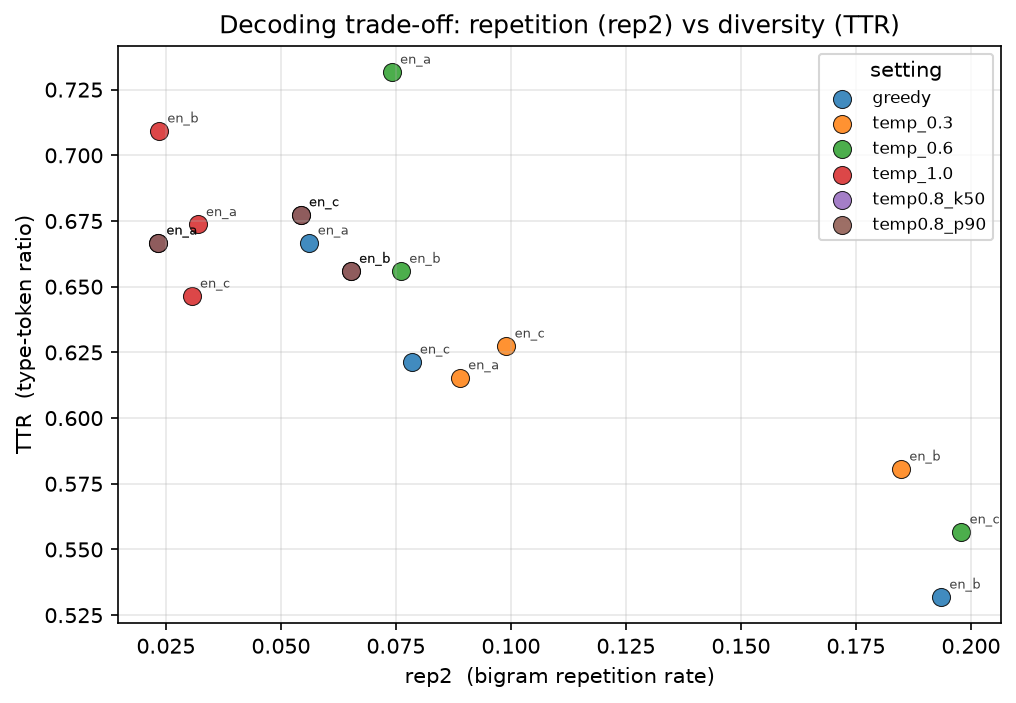

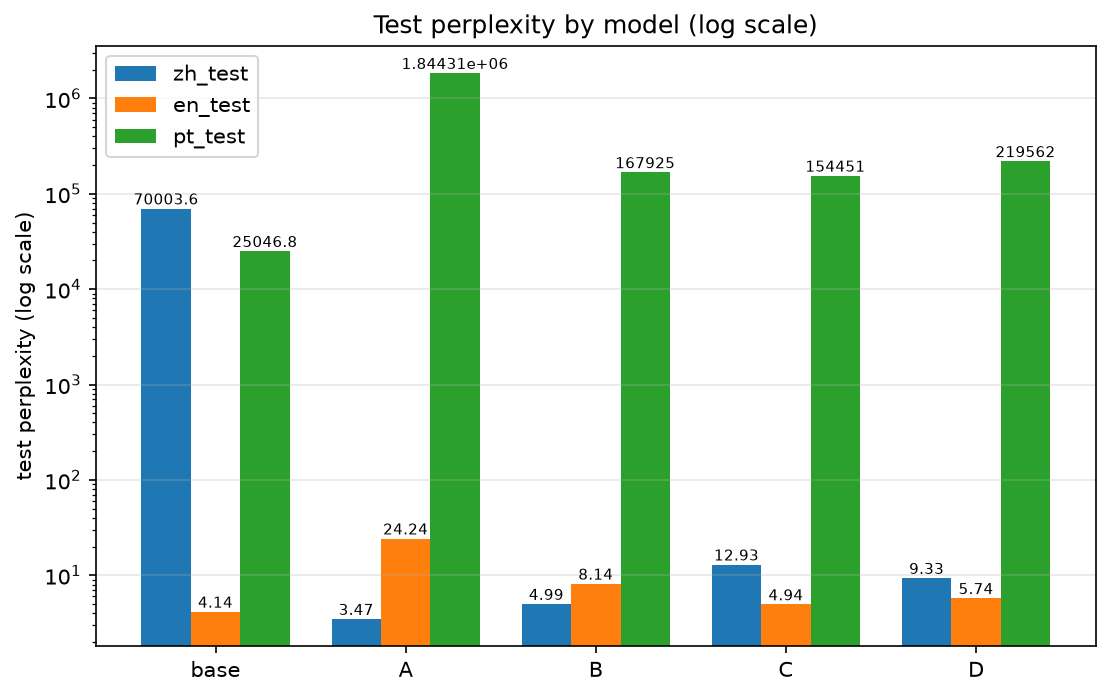

JOB1_OK
C:\Users\07viv\Desktop\CISC7021\assignment1_artifacts\decoding_tradeoff.png
C:\Users\07viv\Desktop\CISC7021\assignment1_artifacts\ppl_summary_log.png


In [43]:
# -*- coding: utf-8 -*-
"""JOB 1 - Visualization (no training). Appended to the assignment notebook."""
import os, sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

OUT_DIR = r"C:\Users\07viv\Desktop\CISC7021\assignment1_artifacts"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------- (a) decoding trade-off: rep2 vs TTR, coloured by setting ----------
m = pd.read_csv(os.path.join(OUT_DIR, "task1_metrics.csv"))
settings = list(dict.fromkeys(m["setting"].tolist()))
cmap = plt.get_cmap("tab10")

fig, ax = plt.subplots(figsize=(7.6, 5.0))
for i, s in enumerate(settings):
    sub = m[m["setting"] == s]
    ax.scatter(sub["rep2"], sub["ttr"], s=75, alpha=0.85, label=s,
               color=cmap(i % 10), edgecolors="black", linewidths=0.5)
for _, r in m.iterrows():
    ax.annotate(r["prompt"], (r["rep2"], r["ttr"]), textcoords="offset points",
                xytext=(4, 4), fontsize=6, alpha=0.75)
ax.set_xlabel("rep2  (bigram repetition rate)")
ax.set_ylabel("TTR  (type-token ratio)")
ax.set_title("Decoding trade-off: repetition (rep2) vs diversity (TTR)")
ax.grid(alpha=0.3)
ax.legend(title="setting", fontsize=8)
P1 = os.path.join(OUT_DIR, "decoding_tradeoff.png")
fig.savefig(P1, dpi=150, bbox_inches="tight")
plt.close(fig)

# ---------------- (b) grouped bar chart of PPL on log scale ------------------------
s = pd.read_csv(os.path.join(OUT_DIR, "final_summary.csv"))
models = s["model"].astype(str).tolist()
cols = ["zh_test", "en_test", "pt_test"]
x = np.arange(len(models))
w = 0.26
fig, ax = plt.subplots(figsize=(8.6, 5.2))
for j, c in enumerate(cols):
    vals = s[c].astype(float).tolist()
    bars = ax.bar(x + (j - 1) * w, vals, w, label=c)
    for b, v in zip(bars, vals):
        ax.annotate(f"{v:g}", (b.get_x() + b.get_width() / 2, v),
                    textcoords="offset points", xytext=(0, 2),
                    ha="center", fontsize=7)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("test perplexity (log scale)")
ax.set_title("Test perplexity by model (log scale)")
ax.grid(alpha=0.3, axis="y")
ax.legend()
P2 = os.path.join(OUT_DIR, "ppl_summary_log.png")
fig.savefig(P2, dpi=150, bbox_inches="tight")
plt.close(fig)

print("JOB1_OK")
print(P1)
print(P2)


### 7.2 - Task-4 translation quality check (CPU, ~10 min)

In [ ]:
# -*- coding: utf-8 -*-
"""7.2- Task-4 translation quality control (CPU only)."""
import os, io, sys, json, random, statistics

try:
    sys.stdout.reconfigure(encoding="utf-8")
except Exception:
    pass

OUT_DIR = r"C:\Users\07viv\Desktop\CISC7021\assignment1_artifacts"
DATA_DIR = r"C:\Users\07viv\Desktop\CISC7021\Model and Datasets\data"
EXTRA = os.path.join(OUT_DIR, "task4_extra_zh.jsonl")
ZH_TRAIN = os.path.join(DATA_DIR, "zh_train.jsonl")


def read_texts(path):
    out = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            if line.strip():
                out.append(json.loads(line)["text"])
    return out


def quality(texts):
    n = len(texts)
    empty = sum(1 for t in texts if t.strip() == "")
    short = sum(1 for t in texts if len(t.strip()) < 50)
    repl = sum(1 for t in texts if "\ufffd" in t)
    lens = [len(t) for t in texts]
    return {
        "n": n,
        "empty": empty, "empty_pct": round(100.0 * empty / n, 4),
        "short_lt50": short, "short_lt50_pct": round(100.0 * short / n, 4),
        "contains_replacement_char": repl,
        "contains_replacement_char_pct": round(100.0 * repl / n, 4),
        "char_len_mean": round(statistics.mean(lens), 4),
        "char_len_median": statistics.median(lens),
        "char_len_min": min(lens), "char_len_max": max(lens),
    }


extra = read_texts(EXTRA)
train = read_texts(ZH_TRAIN)

qc_extra = quality(extra)
qc_train = quality(train)

random.seed(0)
idx = random.sample(range(len(extra)), 5)
samples = [{"index": i, "chars": len(extra[i]), "text": extra[i]} for i in idx]

print("=== JOB 2 / Task-4 translation QC ===")
print(f"task4_extra_zh.jsonl : n={qc_extra['n']}")
print(f"  empty            : {qc_extra['empty']} ({qc_extra['empty_pct']}%)")
print(f"  len < 50 chars   : {qc_extra['short_lt50']} ({qc_extra['short_lt50_pct']}%)")
print(f"  contains U+FFFD  : {qc_extra['contains_replacement_char']} "
      f"({qc_extra['contains_replacement_char_pct']}%)")
print(f"  char len mean/median : {qc_extra['char_len_mean']} / {qc_extra['char_len_median']}")
print(f"zh_train.jsonl       : n={qc_train['n']}")
print(f"  empty            : {qc_train['empty']} ({qc_train['empty_pct']}%)")
print(f"  len < 50 chars   : {qc_train['short_lt50']} ({qc_train['short_lt50_pct']}%)")
print(f"  contains U+FFFD  : {qc_train['contains_replacement_char']} "
      f"({qc_train['contains_replacement_char_pct']}%)")
print(f"  char len mean/median : {qc_train['char_len_mean']} / {qc_train['char_len_median']}")
print("\n--- 5 random sampled translations (seed 0, full text) ---")
for k, s in enumerate(samples, 1):
    print(f"[{k}] idx={s['index']} chars={s['chars']}")
    print(s["text"])
    print("-" * 70)

result = {"task4_extra_zh": qc_extra, "zh_train": qc_train,
          "samples_seed0": samples,
          "source_files": {"task4_extra_zh": EXTRA, "zh_train": ZH_TRAIN}}
QC_PATH = os.path.join(OUT_DIR, "task4_qc.json")
with open(QC_PATH, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print("\nJOB2_OK")
print(f"extra empty={qc_extra['empty']} short<50={qc_extra['short_lt50']} "
      f"ufffd={qc_extra['contains_replacement_char']} "
      f"len_mean={qc_extra['char_len_mean']} len_median={qc_extra['char_len_median']}")
print(f"train empty={qc_train['empty']} short<50={qc_train['short_lt50']} "
      f"ufffd={qc_train['contains_replacement_char']} "
      f"len_mean={qc_train['char_len_mean']} len_median={qc_train['char_len_median']}")
print(QC_PATH)


��= = =   J O B   2   /   T a s k - 4   t r a n s l a t i o n   Q C   = = = 
 
 t a s k 4 _ e x t r a _ z h . j s o n l   :   n = 2 0 0 0 
 
     e m p t y                         :   0   ( 0 . 0 % ) 
 
     l e n   <   5 0   c h a r s       :   0   ( 0 . 0 % ) 
 
     c o n t a i n s   U + F F F D     :   0   ( 0 . 0 % ) 
 
     c h a r   l e n   m e a n / m e d i a n   :   2 3 7 . 5 9 7   /   2 1 9 . 0 
 
 z h _ t r a i n . j s o n l               :   n = 1 0 0 0 0 
 
     e m p t y                         :   0   ( 0 . 0 % ) 
 
     l e n   <   5 0   c h a r s       :   0   ( 0 . 0 % ) 
 
     c o n t a i n s   U + F F F D     :   0   ( 0 . 0 % ) 
 
     c h a r   l e n   m e a n / m e d i a n   :   2 5 8 . 4 1 3   /   2 4 1 . 0 
 
 
 
 - - -   5   r a n d o m   s a m p l e d   t r a n s l a t i o n s   ( s e e d   0 ,   f u l l   t e x t )   - - - 
 
 [ 1 ]   i d x = 1 7 2 9   c h a r s = 2 5 3 
 
 	g N!k, 	g N*N�S�R�v�N. �R�U"kZPv`�N. �N
N,TĉR. �N	g�e�Ǐf[!h, wPp�vQ�Ni[P[�v�swQ. 	

### 7.3 - Multi-seed rerun of Run C (seed 123, ~70 min)

In [ ]:
# -*- coding: utf-8 -*-
"""7.3 - Multi-seed rerun of Run C (seed=123), self-contained.

Rebuilds the same zh_train blocks, trains a fresh llama-42m with EXACTLY Run C's
hyper-parameters except seed=123, saves to saved_models\\run_C_seed123_final and
evaluates zh_test / en_test perplexity with the notebook's compute_ppl logic.
Resumes from the latest checkpoint-* if one exists (save_steps=200, save_only_model).
"""
import os, io, sys, json, gc, time, math, statistics

try:
    sys.stdout.reconfigure(encoding="utf-8")
except Exception:
    pass

import numpy as np
import torch
import torch.utils.data as tud
from torch.nn import CrossEntropyLoss
from transformers import AutoTokenizer, LlamaForCausalLM, TrainingArguments, Trainer

SEED = 123
LR = 1e-4
WD = 0.01
EPOCHS = 2
BSZ = 32
BLOCK = 512
SAVE_STEPS = 200
LOG_STEPS = 50

DATA_DIR  = r"C:\Users\07viv\Desktop\CISC7021\Model and Datasets\data"
MODEL_DIR = r"C:\Users\07viv\Desktop\CISC7021\Model and Datasets\llama-42m"
OUT_DIR   = r"C:\Users\07viv\Desktop\CISC7021\assignment1_artifacts"
FINAL_ROOT = r"C:\Users\07viv\Desktop\CISC7021\saved_models"

TRAIN_FILE = os.path.join(DATA_DIR, "zh_train.jsonl")
VALID_FILE = os.path.join(DATA_DIR, "zh_dev.jsonl")
ZH_TEST_FILE = os.path.join(DATA_DIR, "zh_test.jsonl")
EN_TEST_FILE = os.path.join(DATA_DIR, "en_test.jsonl")

RUN_DIR = os.path.join(OUT_DIR, "runs", "run_C_seed123")
FINAL_DIR = os.path.join(FINAL_ROOT, "run_C_seed123_final")
SEED_JSON = os.path.join(OUT_DIR, "seed_study.json")
PROGRESS = os.path.join(os.path.dirname(os.path.abspath(__file__)), "job3_progress.json")

ORIG_C = {"seed": 42, "zh_test": 12.93, "en_test": 4.94, "pt_test": 154450.56,
          "source": r"saved_models\run_C_final (existing artifact)"}


def stamp(msg):
    line = time.strftime("[%H:%M:%S] ") + msg
    print(line, flush=True)
    try:
        with open(PROGRESS, "w", encoding="utf-8") as f:
            json.dump({"last": line, "ts": time.time()}, f, ensure_ascii=False)
    except Exception:
        pass


def seed_all(s):
    torch.manual_seed(s)
    np.random.seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)


device = "cuda" if torch.cuda.is_available() else "cpu"
seed_all(SEED)
stamp(f"device={device} seed={SEED} torch={torch.__version__}")

# ---- free GPU memory before the run -------------------------------------------
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    stamp("gpu mem freed | allocated(GB)=" +
          str(round(torch.cuda.memory_allocated() / 1e9, 3)))

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


# ---- notebook helpers (identical logic) ---------------------------------------
def _read_jsonl_texts(path):
    out = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            if line.strip():
                out.append(json.loads(line)["text"])
    return out


class SimpleDS(tud.Dataset):
    def __init__(self, blocks):
        self.blocks = blocks

    def __len__(self):
        return len(self.blocks)

    def __getitem__(self, i):
        t = torch.tensor(self.blocks[i], dtype=torch.long)
        return {"input_ids": t, "labels": t, "attention_mask": torch.ones_like(t)}


def _texts_to_blocks(texts, block_size):
    enc = tokenizer(texts, add_special_tokens=False)
    ids = [i for t in enc["input_ids"] for i in t]
    total = (len(ids) // block_size) * block_size
    return [ids[i:i + block_size] for i in range(0, total, block_size)]


def compute_ppl(model, tokenizer, texts, batch_size=16, use_fp16=True):
    encodings = tokenizer(texts, add_special_tokens=False, truncation=False, return_tensors=None)
    encoded_texts, attn_masks = [], []
    for ids, mask in zip(encodings["input_ids"], encodings["attention_mask"]):
        encoded_texts.append(torch.tensor(ids, dtype=torch.long))
        attn_masks.append(torch.tensor(mask, dtype=torch.long))
    encoded_texts = torch.nn.utils.rnn.pad_sequence(encoded_texts, batch_first=True,
                                                    padding_value=tokenizer.pad_token_id)
    attn_masks = torch.nn.utils.rnn.pad_sequence(attn_masks, batch_first=True, padding_value=0)
    if tokenizer.bos_token_id is not None:
        bos = torch.full((encoded_texts.size(0), 1), tokenizer.bos_token_id, dtype=torch.long)
        encoded_texts = torch.cat([bos, encoded_texts], dim=1)
        attn_masks = torch.cat([torch.ones_like(bos), attn_masks], dim=1)
    loss_fct = CrossEntropyLoss(reduction="none")
    nlls = []
    for i in range(0, len(encoded_texts), batch_size):
        enc_batch = encoded_texts[i:i + batch_size].to(device)
        attn_batch = attn_masks[i:i + batch_size].to(device)
        labels = enc_batch
        with torch.no_grad():
            if use_fp16 and device == "cuda":
                with torch.autocast("cuda", dtype=torch.float16):
                    logits = model(enc_batch, attention_mask=attn_batch).logits
            else:
                logits = model(enc_batch, attention_mask=attn_batch).logits
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()
            shift_attn = attn_batch[..., 1:].float()
            loss = loss_fct(shift_logits.transpose(1, 2), shift_labels).float()
            per_doc = torch.exp((loss * shift_attn).sum(1) / shift_attn.sum(1))
            nlls.extend(per_doc.tolist())
    return {"perplexities": nlls, "mean_ppl": sum(nlls) / len(nlls),
            "median_ppl": statistics.median(nlls), "min_ppl": min(nlls), "max_ppl": max(nlls)}


def load_texts(path, limit=None):
    texts = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            texts.append(json.loads(line)["text"])
            if limit and len(texts) >= limit:
                break
    return texts


# ---- (a) rebuild training data ------------------------------------------------
stamp("tokenizing zh_train / zh_dev ...")
train_raw = _read_jsonl_texts(TRAIN_FILE)
valid_raw = _read_jsonl_texts(VALID_FILE)
train_blocks = _texts_to_blocks(train_raw, BLOCK)
valid_blocks = _texts_to_blocks(valid_raw, BLOCK)
lm_datasets = {"train": SimpleDS(train_blocks), "validation": SimpleDS(valid_blocks)}
stamp(f"zh_train raw={len(train_raw)} -> blocks={len(train_blocks)} | "
      f"zh_dev raw={len(valid_raw)} -> blocks={len(valid_blocks)}")

# ---- (b)/(c) train unless the final folder already exists ---------------------
train_info = {"skipped": True, "run_dir": RUN_DIR, "final_dir": FINAL_DIR}
os.makedirs(os.path.join(OUT_DIR, "runs"), exist_ok=True)
os.makedirs(FINAL_ROOT, exist_ok=True)

if os.path.isdir(FINAL_DIR):
    stamp(f"final dir exists, skip training -> {FINAL_DIR}")
else:
    resume = None
    if os.path.isdir(RUN_DIR):
        cks = sorted([d for d in os.listdir(RUN_DIR) if d.startswith("checkpoint-")],
                     key=lambda s: int(s.split("-")[-1]))
        if cks:
            resume = os.path.join(RUN_DIR, cks[-1])
    stamp(f"resume_from_checkpoint={resume}")
    model_now = LlamaForCausalLM.from_pretrained(MODEL_DIR).to(device)
    args = TrainingArguments(
        RUN_DIR,
        learning_rate=LR, weight_decay=WD, seed=SEED,
        per_device_train_batch_size=BSZ, per_device_eval_batch_size=16,
        num_train_epochs=EPOCHS, fp16=True, optim="adamw_torch",
        lr_scheduler_type="linear", warmup_ratio=0.01,
        adam_beta1=0.9, adam_beta2=0.98,
        eval_strategy="steps", eval_steps=SAVE_STEPS,
        save_strategy="steps", save_steps=SAVE_STEPS,
        logging_strategy="steps", logging_steps=LOG_STEPS,
        save_total_limit=2, save_only_model=True, report_to=None)
    trainer = Trainer(model=model_now, args=args,
                      train_dataset=lm_datasets["train"], eval_dataset=lm_datasets["validation"])
    t0 = time.time()
    trainer.train(resume_from_checkpoint=resume)
    dur = (time.time() - t0) / 60.0
    trainer.save_model(FINAL_DIR)
    train_info = {"skipped": False, "run_dir": RUN_DIR, "final_dir": FINAL_DIR,
                  "duration_min": round(dur, 2), "steps": trainer.state.global_step,
                  "log_history": trainer.state.log_history}
    with open(os.path.join(OUT_DIR, "train_C_seed123.json"), "w", encoding="utf-8") as f:
        json.dump({"run": "C_seed123", "seed": SEED, "lr": LR, "epochs": EPOCHS,
                   "weight_decay": WD, "batch_size": BSZ, **train_info}, f,
                  ensure_ascii=False, indent=1)
    stamp(f"training done {dur:.1f} min, steps={trainer.state.global_step} -> {FINAL_DIR}")
    del trainer, model_now
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ---- (d) evaluate zh_test / en_test PPL ---------------------------------------
stamp("loading run_C_seed123_final for PPL evaluation ...")
m = LlamaForCausalLM.from_pretrained(FINAL_DIR).to(device)
m.eval()
ppl = {}
for name, path in [("zh_test", ZH_TEST_FILE), ("en_test", EN_TEST_FILE)]:
    texts = load_texts(path)
    res = compute_ppl(m, tokenizer, texts)
    ppl[name] = res["mean_ppl"]
    stamp(f"{name}: n={len(texts)} mean_ppl={res['mean_ppl']:.4f} "
          f"median={res['median_ppl']:.4f} min={res['min_ppl']:.4f} max={res['max_ppl']:.4f}")
del m
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ---- (e) two-seed statistics --------------------------------------------------
def two_seed_stat(a, b):
    vals = [float(a), float(b)]
    mean = sum(vals) / 2.0
    sample_std = math.sqrt(sum((v - mean) ** 2 for v in vals) / 1.0)  # ddof=1
    pop_std = math.sqrt(sum((v - mean) ** 2 for v in vals) / 2.0)     # ddof=0
    return {"values": vals, "seed42": vals[0], "seed123": vals[1], "n_seeds": 2,
            "mean": round(mean, 4), "std_sample_ddof1": round(sample_std, 4),
            "std_population_ddof0": round(pop_std, 4)}

zh_stat = two_seed_stat(ORIG_C["zh_test"], ppl["zh_test"])
en_stat = two_seed_stat(ORIG_C["en_test"], ppl["en_test"])

result = {
    "task": "JOB3 multi-seed rerun of Run C",
    "settings": {"base_model": MODEL_DIR, "train_file": TRAIN_FILE,
                 "blocks": {"train": len(train_blocks), "validation": len(valid_blocks),
                            "block_size": BLOCK},
                 "lr": LR, "weight_decay": WD, "epochs": EPOCHS, "batch_size": BSZ,
                 "fp16": True, "optim": "adamw_torch", "lr_scheduler": "linear",
                 "warmup_ratio": 0.01, "eval_steps": SAVE_STEPS, "log_steps": LOG_STEPS,
                 "seed": SEED},
    "training": {k: v for k, v in train_info.items() if k != "log_history"},
    "runs": {
        "run_C_seed42": ORIG_C,
        "run_C_seed123": {"seed": SEED, "zh_test": ppl["zh_test"], "en_test": ppl["en_test"],
                          "final_dir": FINAL_DIR, "steps": train_info.get("steps"),
                          "duration_min": train_info.get("duration_min")},
    },
    "zh_test": zh_stat,
    "en_test": en_stat,
    "summary": {
        "zh_test": f"seed42={ORIG_C['zh_test']}, seed123={ppl['zh_test']:.2f}, "
                   f"mean={zh_stat['mean']:.2f}, std(ddof=1)={zh_stat['std_sample_ddof1']:.2f}",
        "en_test": f"seed42={ORIG_C['en_test']}, seed123={ppl['en_test']:.2f}, "
                   f"mean={en_stat['mean']:.2f}, std(ddof=1)={en_stat['std_sample_ddof1']:.2f}",
    },
    "note": ("Two-seed study over Run C (lr 1e-4, wd 0.01, 2 epochs, bs 32, fp16, adamw_torch, "
             "linear schedule, warmup_ratio 0.01). Run C seed42 values are the existing "
             "saved_models\\run_C_final artifact; Run C seed123 was retrained here. "
             "Perplexity = fp16 per-document exp(mean NLL), computed with the notebook's "
             "compute_ppl logic."),
}
with open(SEED_JSON, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

stamp(f"zh  : {result['summary']['zh_test']}")
stamp(f"en  : {result['summary']['en_test']}")
stamp("JOB3_OK")
print(SEED_JSON)


[00:38:12] device=cuda seed=123 torch=2.6.0+cu124
[00:38:12] gpu mem freed | allocated(GB)=0.0
[00:38:12] tokenizing zh_train / zh_dev ...
[00:38:15] zh_train raw=10000 -> blocks=7960 | zh_dev raw=500 -> blocks=393
[00:38:15] resume_from_checkpoint=None
{'loss': 6.9554, 'grad_norm': 2.1203725337982178, 'learning_rate': 9.168356997971604e-05, 'epoch': 0.2}
{'loss': 4.8017, 'grad_norm': 11.297005653381348, 'learning_rate': 8.154158215010142e-05, 'epoch': 0.4}
{'loss': 4.4092, 'grad_norm': 8.459146499633789, 'learning_rate': 7.139959432048681e-05, 'epoch': 0.6}
{'loss': 3.926, 'grad_norm': 7.470520496368408, 'learning_rate': 6.125760649087221e-05, 'epoch': 0.8}
{'eval_loss': 3.72102952003479, 'eval_runtime': 22.7958, 'eval_samples_per_second': 17.24, 'eval_steps_per_second': 1.097, 'epoch': 0.8}
{'loss': 3.4728, 'grad_norm': 5.88940954208374, 'learning_rate': 5.1115618661257614e-05, 'epoch': 1.0}
{'loss': 3.0575, 'grad_norm': 8.110176086425781, 'learning_rate': 4.097363083164301e-05, 'epo

## 8. Conclusions

The full pipeline (decoding, perplexity evaluation, and runs A–D of continual pre-training) took several hours on my RTX 4070 Laptop GPU (8 GB) — run D alone trained for about 69 minutes, and the two 8-epoch runs took much longer. The short version:

- Task 1: greedy decoding is the most repetitive setting. Temperature 1.0 gives the highest TTR and the fewest repeated trigrams, but the text also drifts off topic.
- Task 2: the English-only base model scores PPL around 4 on English, around 70k on Chinese and around 25k on Portuguese. The gap on non-English data is large and easy to measure.
- Task 3: Chinese continual pre-training cuts Chinese PPL by orders of magnitude (base 70,003.65 → 3.47 in run A), but catastrophic forgetting is real rather than absent: English PPL rises from 4.14 to 24.24 when the model trains longest at the highest learning rate. The forgetting is reduced by halving the learning rate (run B, en 8.14), by training for fewer epochs (run C, en 4.94), or by using more data with fewer passes (run D, en 5.74).
- Task 4 (optional): collecting and translating 2,000 extra stories gives the best balance. Run D reaches zh_test PPL 9.33 while keeping English at 5.74 — better Chinese than run C and much better English retention than run A.